In [1]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)


In [2]:
# 1. Load & Prepare

df = loadmat("data/mnist-original.mat")
X = df["data"].T.astype(np.float32)  # (70000, 784)
y = df["label"].T.ravel().astype(int)  # (70000,)


In [3]:
'''img = X[50000].reshape((28,28))
plt.imshow(img,cmap='gray')'''

"img = X[50000].reshape((28,28))\nplt.imshow(img,cmap='gray')"

In [4]:


X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(70000, 784), dtype=float32)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}\n")


Train: (56000, 784)  |  Test: (14000, 784)



In [20]:
# 2. Define 5 Base Models

base_models = [
    (
        "Logistic Regression",
        LogisticRegression(
            max_iter=200, C=1.0, solver="saga", n_jobs=-1, random_state=42
        ),
    ),
    (
        "Random Forest",
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    ),
    ("KNN", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=20, random_state=42)),
    ("NB", GaussianNB(priors=None)),
]


In [21]:
# 3. Train & Evaluate Each Base Model Individually
import time

start = time.time()
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 55)

base_results = {}
for name, model in base_models:
    model.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_sc))
    base_results[name] = acc
    print(f"  {name:<23} {acc * 100:>8.2f}%")
print(f'{'Base model training time is':<20} {time.time() - start}')
print("=" * 55)


Model                       Accuracy
  Logistic Regression        91.84%
  Random Forest              96.71%
  KNN                        94.44%
  Decision Tree              87.69%
  NB                         52.47%
Base model training time is 279.3189814090729


In [22]:
# 4. Build & Train Stacking Ensemble
start=time.time()
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(
        max_iter=500, C=1.0, solver="lbfgs", random_state=42
    ),
    cv=5,  # 5-fold CV to generate meta-features
    passthrough=False,  # only pass base model predictions to meta-model
    n_jobs=-1,
) 
stack.fit(X_train_sc, y_train)

y_pred = stack.predict(X_test_sc)
y_prob = stack.predict_proba(X_test_sc)
acc_stack = accuracy_score(y_test, y_pred)

print(f"\n{'Stacking Ensemble':<25} {acc_stack * 100:>8.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print(f'\n {'Training time':<25} {time.time()-start:.2}s')


Stacking Ensemble            97.41%

Classification Report:
              precision    recall  f1-score   support

           0     0.9793    0.9942    0.9867      1381
           1     0.9911    0.9860    0.9885      1575
           2     0.9743    0.9750    0.9746      1398
           3     0.9719    0.9671    0.9695      1428
           4     0.9771    0.9692    0.9732      1365
           5     0.9737    0.9683    0.9710      1263
           6     0.9797    0.9847    0.9822      1375
           7     0.9673    0.9733    0.9703      1459
           8     0.9727    0.9663    0.9695      1365
           9     0.9527    0.9554    0.9541      1391

    accuracy                         0.9741     14000
   macro avg     0.9740    0.9740    0.9740     14000
weighted avg     0.9742    0.9741    0.9741     14000


 Training time             7.1e+02s


In [23]:
import joblib

joblib.dump(stack, "mnist_model.pkl")

joblib.dump(scaler, "mnist_scaler.pkl")
print("saved")

saved


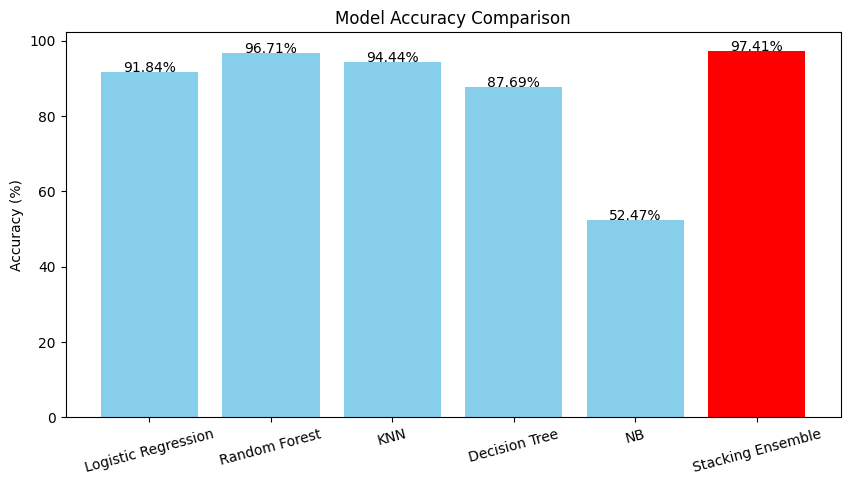

In [24]:
# ── Plot 1: Model Accuracy Comparison
names = list(base_results.keys()) + ["Stacking Ensemble"]

accuracies = [acc * 100 for acc in base_results.values()]
accuracies.append(acc_stack * 100)
colors = ["skyblue"] * 5 + ["red"]
plt.figure(figsize=(10, 5))

bars = plt.bar(names, accuracies,color=colors)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{acc:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.show()

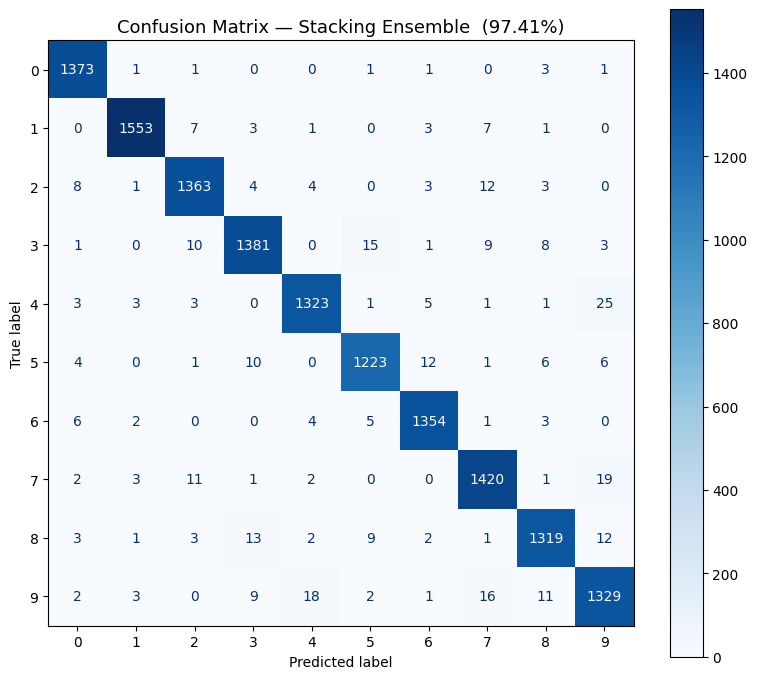

In [26]:
# ── Plot 2: Confusion Matrix (Stacking)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=range(10)).plot(
    ax=ax, colorbar=True, cmap="Blues"
)
ax.set_title(
    f"Confusion Matrix — Stacking Ensemble  ({acc_stack * 100:.2f}%)", fontsize=13
)
plt.tight_layout()

plt.show()


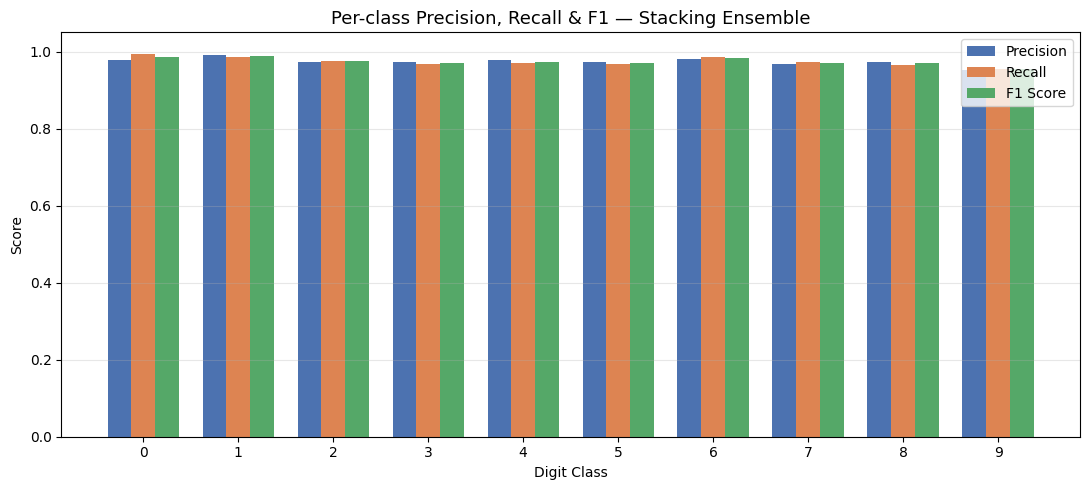

In [27]:
# ── Plot 3: Per-class Precision, Recall, F1 (Stacking)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

x = np.arange(10)
w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, precision, w, label="Precision", color="#4C72B0")
ax.bar(x, recall, w, label="Recall", color="#DD8452")
ax.bar(x + w, f1, w, label="F1 Score", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(range(10))
ax.set_xlabel("Digit Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class Precision, Recall & F1 — Stacking Ensemble", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


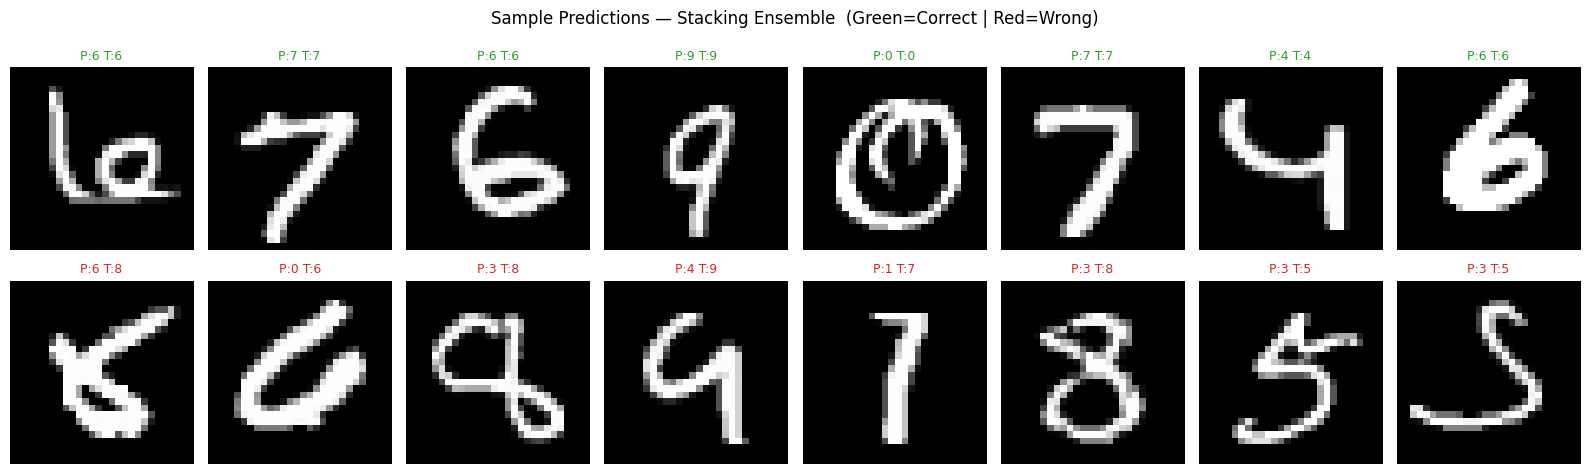

In [28]:
# ── Plot 4: Sample Predictions
rng = np.random.default_rng(42)
wrong_idx = np.where(y_pred != y_test)[0]
correct_idx = np.where(y_pred == y_test)[0]
sample_idx = np.concatenate(
    [
        rng.choice(correct_idx, 8, replace=False),
        rng.choice(wrong_idx, 8, replace=False),
    ]
)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(
    "Sample Predictions — Stacking Ensemble  (Green=Correct | Red=Wrong)", fontsize=12
)
for i, idx in enumerate(sample_idx):
    ax = axes[i // 8][i % 8]
    colour = "#2ca02c" if y_pred[idx] == y_test[idx] else "#d62728"
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"P:{y_pred[idx]} T:{y_test[idx]}", color=colour, fontsize=9)
    ax.axis("off")
axes[0][0].set_ylabel("Correct", fontsize=10, color="#2ca02c")
axes[1][0].set_ylabel("Wrong", fontsize=10, color="#d62728")
plt.tight_layout()

plt.show()


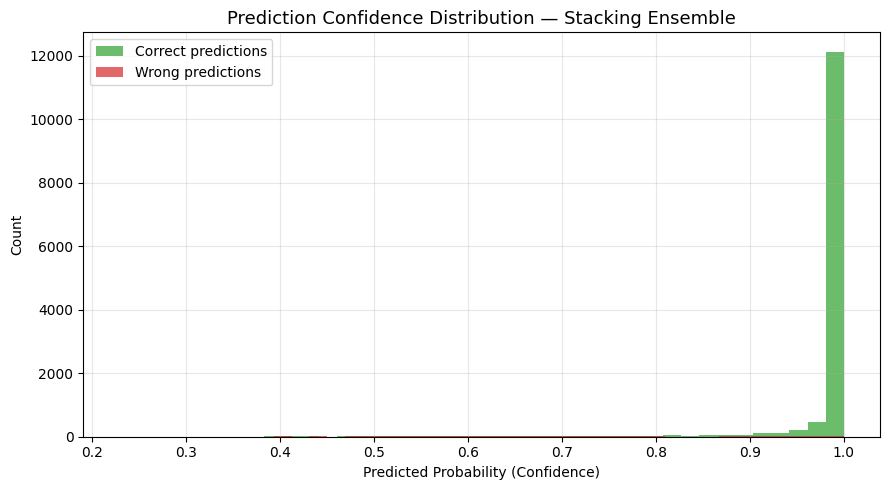

In [29]:
# ── Plot 5: Confidence Distribution
correct_conf = y_prob[np.arange(len(y_test)), y_pred][y_pred == y_test]
wrong_conf = y_prob[np.arange(len(y_test)), y_pred][y_pred != y_test]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(correct_conf, bins=40, alpha=0.7, color="#2ca02c", label="Correct predictions")
ax.hist(wrong_conf, bins=40, alpha=0.7, color="#d62728", label="Wrong predictions")
ax.set_xlabel("Predicted Probability (Confidence)")
ax.set_ylabel("Count")
ax.set_title("Prediction Confidence Distribution — Stacking Ensemble", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.show()


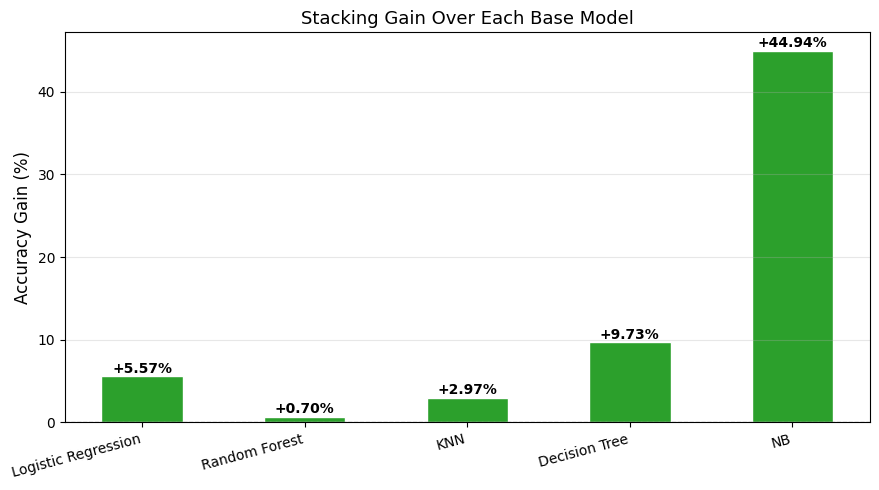

In [30]:
# ── Plot 6: Accuracy gain over base models
gains = {name: (acc_stack - acc) * 100 for name, acc in base_results.items()}
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in gains.values()]
bars = ax.bar(
    gains.keys(), gains.values(), color=bar_colors, edgecolor="white", width=0.5
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Accuracy Gain (%)", fontsize=12)
ax.set_title("Stacking Gain Over Each Base Model", fontsize=13)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, gains.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.05 if val >= 0 else -0.15),
        f"{val:+.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.show()
